In [105]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import yaml
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report
from transformers import AutoTokenizer, AutoModel

from summarizer import Summarizer

In [106]:
with open("../config.yaml") as f:
    _cfg = yaml.safe_load(f)

summarizer_names = [m["name"] for m in _cfg["models"]["summarizers"]]
print(f"Available summarizer models: {summarizer_names}")

_DEFAULT_MODEL = summarizer_names[0] if summarizer_names else None

Available summarizer models: ['classla/bcms-bertic', 'FacebookAI/xlm-roberta-large', 'microsoft/deberta-v3-large']


In [107]:
chapters = [
"""
Gradsko vijeće usvojilo je novi prometni plan nakon višemjesečne rasprave. Prijedlog uključuje širenje autobusnih traka, izgradnju zaštićenih biciklističkih staza i modernizaciju prometne signalizacije. Dužnosnici tvrde da će promjene smanjiti gužve, poboljšati sigurnost i smanjiti emisije u sljedećem desetljeću. Neki stanovnici podržavaju okolišne koristi, dok su drugi zabrinuti zbog kašnjenja radova i gubitka parkirnih mjesta. Prva faza projekta trebala bi početi u rujnu.
""",
"""
Za prekršaje iz člana 3. stava 1. i člana 6, 8, 11. i 12. ovoga zakona može se uz kaznu zatvora ili samostalno izreći i zaštitna mjera udaljenja s područja općine na kojem je izvršen prekršaj u trajanju od 30 dana do šest mjeseci. Zaštitna mjera iz stava 1. ovoga člana može se izreći osobi u pogledu koje se iz okolnosti pod kojima je prekršaj izvršila iz pobuda, ranijeg života, osobnih prilika i njenog držanja može osnovano smatrati da bi na istom području mogla ponovno izvršiti koji od prekršaja iz stava 1. ovoga člana. Nitko ne može biti udaljen s područja općine na kojem ima prebivalište. U rješenju o prekršaju odredit će se rok u kojem je okrivljeni dužan napustiti područje općine na kojem je učinio prekršaj, a koji ne može biti kraći od 12 sati niti duži od tri dana. Žalba protiv rješenja ne odgađa izvršenje ove zaštitne mjere. Tko se u roku iz stava 4. ovoga člana ne udalji ili tko se za vrijeme trajanja zaštitne mjere udaljenja bez opravdanog razloga vrati na područje s koga je udaljen, kaznit će se za taj prekršaj novčanom kaznom od 50 do 500 dinara ili kaznom zatvora do 30 dana.
""",
"""
Dobrovoljni prilozi ne smiju se zahtijevati ili prikupljati bez odobrenja. ako zakonom nije drukčije određeno. Odredba stava 1. ovoga člana ne odnosi se na dobrovoljne priloge što ih prikupljaju društveno-političke organizacije, mjesne zajednice, organizacije udruženog rada druge samoupravne organizacije i zajednice i društvene organizacije. Odobrenje za prikupljanje dobrovoljnih priloga na području općine izdaje općinski sekretarijat za unutrašnje poslove. Općinski sekretarijat za unutrašnje poslove može odbiti izdavanje odobrenja za prikupljanje dobrovoljnih priloga ako ocijeni da bi se time remetio javni red i mir ili uznemirivali građani. Tko prikuplja dobrovoljne priloge bez odobrenja, kaznit će se novčanom kaznom od 50 do 500 dinara ili kaznom zatvora do 30 dana. Prilozi prikupljeni bez odobrenja oduzet će se u korist općine.
"""
]

GROUND_TRUTH_PER_CHAPTER = [
    {1, 2, 3},   # chapter 0
    {0, 2, 4},   # chapter 1
    {0, 1, 4},   # chapter 2
]

NUM_SENTENCES = 3

In [108]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

all_model_results = []

for model_name in summarizer_names:
    print(f"\n{'='*60}\nEvaluating model: {model_name}\n{'='*60}\n")
    
    summarizer = Summarizer(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    
    all_y_true, all_y_pred = [], []
    chapter_metrics = []
    
    for idx, (text, ground_truth_indices) in enumerate(zip(chapters, GROUND_TRUTH_PER_CHAPTER)):
        sentences = summarizer.split_sentences(text.strip())
        
        sentence_embeddings = summarizer.embed_texts(sentences, tokenizer, model, device=device)
        doc_embedding       = summarizer.embed_texts([text],    tokenizer, model, device=device)
        selected_indices    = set(summarizer.mmr_select(sentence_embeddings, doc_embedding, num_sentences=NUM_SENTENCES))
        summary             = " ".join(sentences[i] for i in sorted(selected_indices))
        
        y_true = [1 if i in ground_truth_indices else 0 for i in range(len(sentences))]
        y_pred = [1 if i in selected_indices      else 0 for i in range(len(sentences))]
        
        all_y_true.extend(y_true)
        all_y_pred.extend(y_pred)
        
        p  = precision_score(y_true, y_pred, zero_division=0)
        r  = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        
        chapter_metrics.append({"precision": p, "recall": r, "f1": f1, "cm": cm})
        
        print(f"══ Chapter {idx + 1} {'═' * 50}")
        print(f"Summary        : {summary[:150]}...")
        print(f"Sentences      : {len(sentences)}")
        print(f"Selected idx   : {sorted(selected_indices)}")
        print(f"Ground-truth   : {sorted(ground_truth_indices)}")
        print(f"Precision: {p:.4f}  Recall: {r:.4f}  F1: {f1:.4f}")
    
    agg_p  = precision_score(all_y_true, all_y_pred, zero_division=0)
    agg_r  = recall_score(all_y_true, all_y_pred, zero_division=0)
    agg_f1 = f1_score(all_y_true, all_y_pred, zero_division=0)
    agg_cm = confusion_matrix(all_y_true, all_y_pred, labels=[0, 1])
    
    print(f"\n══ Aggregate (all chapters) for {model_name} {'═' * 30}")
    print(classification_report(all_y_true, all_y_pred, target_names=["Not selected", "Selected"], zero_division=0))
    print(f"Precision: {agg_p:.4f}  Recall: {agg_r:.4f}  F1: {agg_f1:.4f}")
    
    all_model_results.append({
        "model": model_name,
        "chapter_metrics": chapter_metrics,
        "precision": agg_p,
        "recall": agg_r,
        "f1": agg_f1,
        "cm": agg_cm,
        "all_y_true": all_y_true,
        "all_y_pred": all_y_pred,
    })

Using device: cuda

Evaluating model: classla/bcms-bertic



Loading weights: 100%|██████████| 197/197 [00:00<00:00, 100814.77it/s]


══ Chapter 1 ══════════════════════════════════════════════════
Summary        : Prijedlog uključuje širenje autobusnih traka, izgradnju zaštićenih biciklističkih staza i modernizaciju prometne signalizacije. Dužnosnici tvrde da će...
Sentences      : 5
Selected idx   : [1, 2, 3]
Ground-truth   : [1, 2, 3]
Precision: 1.0000  Recall: 1.0000  F1: 1.0000
══ Chapter 2 ══════════════════════════════════════════════════
Summary        : ovoga zakona može se uz kaznu zatvora ili samostalno izreći i zaštitna mjera udaljenja s područja općine na kojem je izvršen prekršaj u trajanju od 30...
Sentences      : 13
Selected idx   : [4, 9, 12]
Ground-truth   : [0, 2, 4]
Precision: 0.3333  Recall: 0.3333  F1: 0.3333
══ Chapter 3 ══════════════════════════════════════════════════
Summary        : ovoga člana ne odnosi se na dobrovoljne priloge što ih prikupljaju društveno-političke organizacije, mjesne zajednice, organizacije udruženog rada dru...
Sentences      : 8
Selected idx   : [3, 5, 6]
Ground-tr

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 17444.66it/s]


══ Chapter 1 ══════════════════════════════════════════════════
Summary        : Prijedlog uključuje širenje autobusnih traka, izgradnju zaštićenih biciklističkih staza i modernizaciju prometne signalizacije. Dužnosnici tvrde da će...
Sentences      : 5
Selected idx   : [1, 2, 3]
Ground-truth   : [1, 2, 3]
Precision: 1.0000  Recall: 1.0000  F1: 1.0000
══ Chapter 2 ══════════════════════════════════════════════════
Summary        : ovoga člana može se izreći osobi u pogledu koje se iz okolnosti pod kojima je prekršaj izvršila iz pobuda, ranijeg života, osobnih prilika i njenog dr...
Sentences      : 13
Selected idx   : [6, 9, 12]
Ground-truth   : [0, 2, 4]
Precision: 0.0000  Recall: 0.0000  F1: 0.0000
══ Chapter 3 ══════════════════════════════════════════════════
Summary        : ovoga člana ne odnosi se na dobrovoljne priloge što ih prikupljaju društveno-političke organizacije, mjesne zajednice, organizacije udruženog rada dru...
Sentences      : 8
Selected idx   : [3, 5, 6]
Ground-tr

Loading weights: 100%|██████████| 390/390 [00:00<00:00, 99210.25it/s]


══ Chapter 1 ══════════════════════════════════════════════════
Summary        : Prijedlog uključuje širenje autobusnih traka, izgradnju zaštićenih biciklističkih staza i modernizaciju prometne signalizacije. Dužnosnici tvrde da će...
Sentences      : 5
Selected idx   : [1, 2, 3]
Ground-truth   : [1, 2, 3]
Precision: 1.0000  Recall: 1.0000  F1: 1.0000
══ Chapter 2 ══════════════════════════════════════════════════
Summary        : ovoga zakona može se uz kaznu zatvora ili samostalno izreći i zaštitna mjera udaljenja s područja općine na kojem je izvršen prekršaj u trajanju od 30...
Sentences      : 13
Selected idx   : [4, 9, 12]
Ground-truth   : [0, 2, 4]
Precision: 0.3333  Recall: 0.3333  F1: 0.3333
══ Chapter 3 ══════════════════════════════════════════════════
Summary        : ovoga člana ne odnosi se na dobrovoljne priloge što ih prikupljaju društveno-političke organizacije, mjesne zajednice, organizacije udruženog rada dru...
Sentences      : 8
Selected idx   : [3, 5, 6]
Ground-tr


════════════════════════════════════════════════════════════
VISUALIZATION: Separate subplots per metric + CM grid
════════════════════════════════════════════════════════════



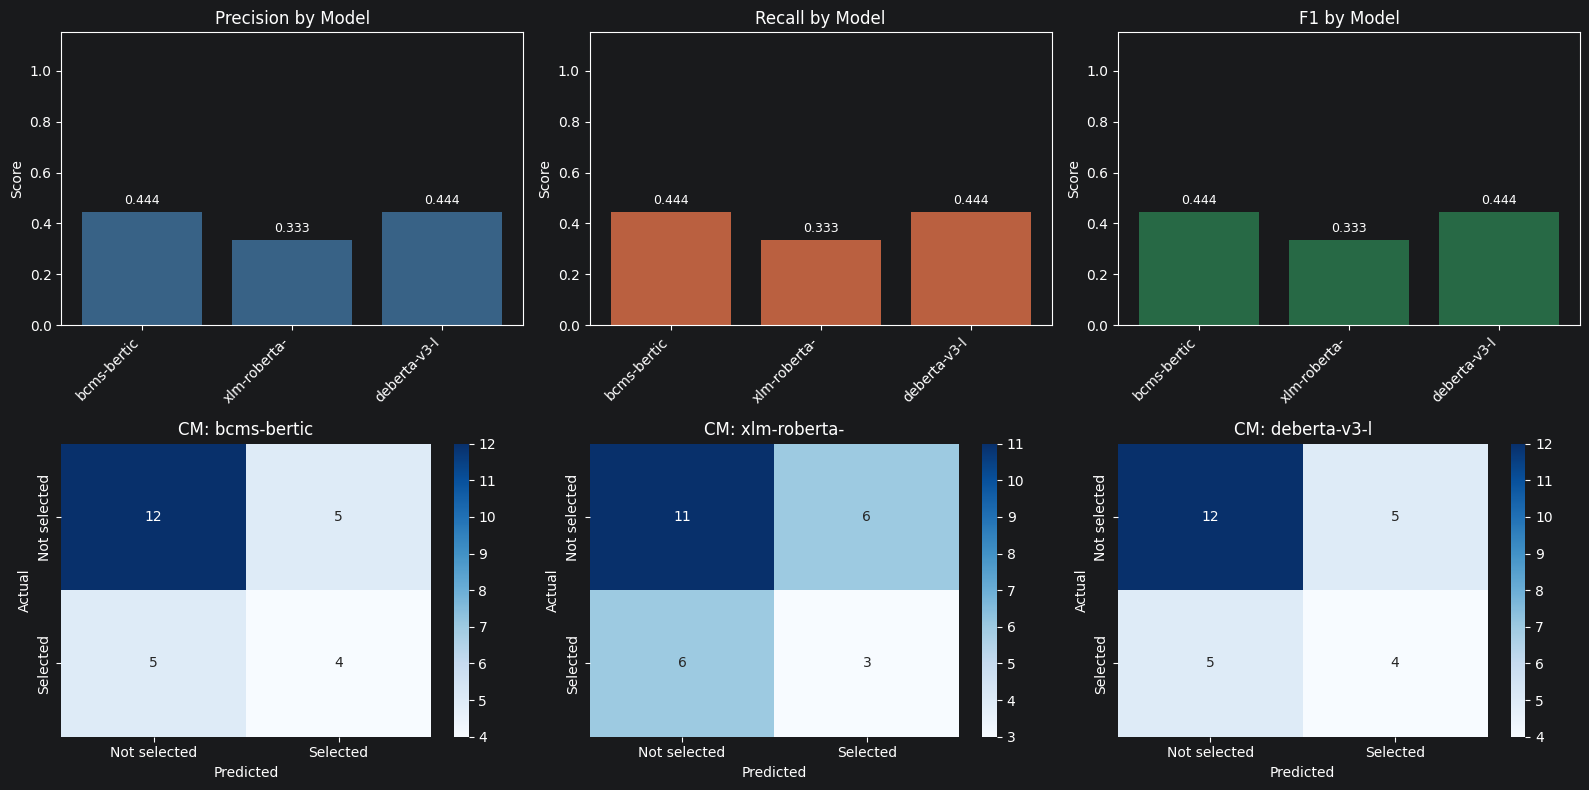

In [109]:
print("\n" + "═" * 60)
print("VISUALIZATION: Separate subplots per metric + CM grid")
print("═" * 60 + "\n")

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

metrics = ["precision", "recall", "f1"]
colors = ["steelblue", "coral", "seagreen"]

for m_idx, (metric, color) in enumerate(zip(metrics, colors)):
    ax = axes[0, m_idx]
    vals = [r[metric] for r in all_model_results]
    bars = ax.bar(range(n_models), vals, color=color, alpha=0.7)
    ax.set_xticks(range(n_models))
    ax.set_xticklabels(model_names_short, rotation=45, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_title(f"{metric.capitalize()} by Model")
    ax.set_ylabel("Score")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{val:.3f}", 
               ha="center", va="bottom", fontsize=9)

for idx, r in enumerate(all_model_results):
    ax = axes[1, idx]
    sns.heatmap(r["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not selected", "Selected"],
                yticklabels=["Not selected", "Selected"],
                ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"CM: {model_names_short[idx]}")

for idx in range(len(all_model_results), 3):
    axes[1, idx].axis("off")

plt.tight_layout()
plt.show()